In [50]:
# To check if GPU is active
from tensorflow.python.client import device_lib

# Load Data
from os import listdir
from os.path import join
import cv2
import numpy as np

# Data Visualisation
import matplotlib.pyplot as plt

# Model Training
from tensorflow.keras import utils
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from sklearn.model_selection import train_test_split

In [51]:
train_path = "/Users/vaisakh/programs/research/dataset/asl_alphabet_train"
test_path = "/Users/vaisakh/programs/research/dataset/asl_alphabet_test"

In [52]:
classes = {
    'A': 0,  'B': 1,  'C': 2,  'D': 3,  'E': 4,  'F': 5,  'G': 6,  'H': 7,  'I': 8,  'J': 9,  
    'K': 10,  'L': 11,  'M': 12,  'N': 13,  'O': 14,  'P': 15,  'Q': 16,  'R': 17,  'S': 18,  'T': 19,  
    'U': 20,  'V': 21,  'W': 22,  'X': 23,  'Y': 24,  'Z': 25,  'del': 26,  'nothing': 27,  'space': 28,
}

In [53]:
def load_data(path):
    image = []
    labels = []
    for label_dir in listdir(path):
        for img_name in listdir(join(train_path, label_dir)):
            img = cv2.imread(join(train_path, label_dir, img_name))
            image.append(cv2.resize(img, (32, 32)))
            labels.append(classes[label_dir])
    return image, labels

x, y = load_data(train_path)

In [54]:
print(len(x))
print(len(y))

87000
87000


In [55]:
def preprocess(x, y):
    x = np.array(x)
    norm_x = x/255
    y = utils.to_categorical(y)
    return train_test_split(x, y, test_size=.2)

In [56]:
x_train, x_test, y_train, y_test = preprocess(x, y)

<h3>CNN</h3>

In [57]:
batch = 32
epochs = 15
learning_rate = 0.001

In [58]:
model = Sequential()

model.add(Conv2D(64, (3, 3), padding='same', input_shape=(32, 32, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())

model.add(Conv2D(128, (3, 3), padding='same', input_shape=(32, 32, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Conv2D(256, (3, 3), padding='same', input_shape=(32, 32, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(BatchNormalization())

model.add(Flatten())
model.add(Dropout(0.2))
model.add(Dense(1024, activation='relu'))
model.add(Dense(len(classes), activation='softmax'))

model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])

In [59]:
model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_21 (Conv2D)          (None, 32, 32, 64)        1792      
                                                                 
 max_pooling2d_21 (MaxPoolin  (None, 16, 16, 64)       0         
 g2D)                                                            
                                                                 
 batch_normalization_21 (Bat  (None, 16, 16, 64)       256       
 chNormalization)                                                
                                                                 
 conv2d_22 (Conv2D)          (None, 16, 16, 128)       73856     
                                                                 
 max_pooling2d_22 (MaxPoolin  (None, 8, 8, 128)        0         
 g2D)                                                            
                                                      

In [60]:
history = model.fit(x_train, y_train, batch_size=batch, epochs=epochs, validation_split=0.2, shuffle = True, verbose=1)

Epoch 1/15


2022-12-19 02:45:24.398441: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1740/1740 [==============================] - ETA: 0s - loss: 0.6612 - accuracy: 0.8048

2022-12-19 02:46:05.406692: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1740/1740 [==============================] - 46s 24ms/step - loss: 0.6612 - accuracy: 0.8048 - val_loss: 1.0402 - val_accuracy: 0.7330
Epoch 2/15
1740/1740 [==============================] - 41s 24ms/step - loss: 0.1383 - accuracy: 0.9559 - val_loss: 0.1471 - val_accuracy: 0.9528
Epoch 3/15
1740/1740 [==============================] - 41s 24ms/step - loss: 0.0923 - accuracy: 0.9739 - val_loss: 0.2048 - val_accuracy: 0.9501
Epoch 4/15
1740/1740 [==============================] - 42s 24ms/step - loss: 0.0819 - accuracy: 0.9768 - val_loss: 0.1788 - val_accuracy: 0.9531
Epoch 5/15
1740/1740 [==============================] - 40s 23ms/step - loss: 0.0589 - accuracy: 0.9841 - val_loss: 0.1518 - val_accuracy: 0.9608
Epoch 6/15
1740/1740 [==============================] - 40s 23ms/step - loss: 0.0632 - accuracy: 0.9846 - val_loss: 0.6958 - val_accuracy: 0.8702
Epoch 7/15
1740/1740 [==============================] - 41s 24ms/step - loss: 0.0433 - accuracy: 0.9891 - val_loss: 3.9538 - val_accura

In [61]:
model.save("model.bin")

INFO:tensorflow:Assets written to: model.bin/assets


INFO:tensorflow:Assets written to: model.bin/assets


In [66]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)
print('Test loss:', test_loss)

544/544 [==============================] - 6s 11ms/step - loss: 0.0399 - accuracy: 0.9907
Test accuracy: 0.9907471537590027
Test loss: 0.03992335870862007


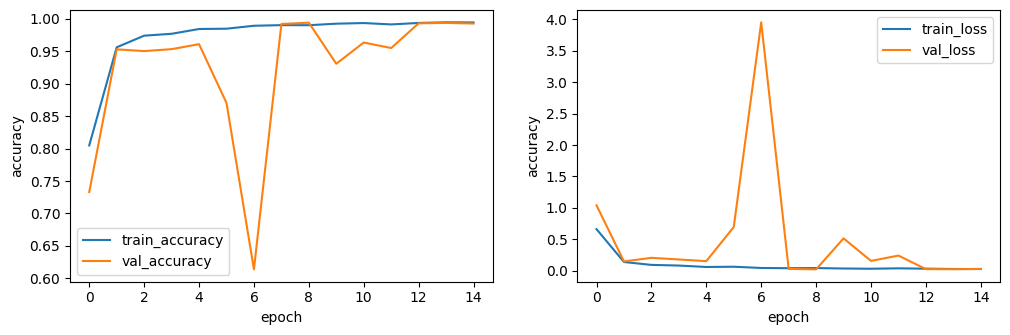

In [68]:
def plot_results(model):
    plt.figure(figsize=(12, 12))
    plt.subplot(3, 2, 1)
    plt.plot(history.history['accuracy'], label = 'train_accuracy')
    plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.legend()
    plt.subplot(3, 2, 2)
    plt.plot(history.history['loss'], label = 'train_loss')
    plt.plot(history.history['val_loss'], label = 'val_loss')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.legend()
    plt.show()


plot_results(model)